# train_two_moons

This notebook shows a minimal, reproducible example for some of the features of the l-DEP implementation.  
A l-DEP estimator will be created, trained on a sample binary dataset (scikit-learn's "two moons" with noise) and its decision boundary will be displayed with matplotlib.

The definition and activation function of the l-DEP, as well as the training method, were implemented based on the works in *Oliveira, Angelica Lourenço, and Marcos Eduardo Valle. "Linear dilation-erosion perceptron trained using a convex-concave procedure." International Conference on Soft Computing and Pattern Recognition. Cham: Springer International Publishing, 2020*.

## 1. Train the l-DEP

First, let us import the needed modules.

For readability purposes, only the bare minimum is included here, the modules used for display can be found at the start of the second section.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

from sklearn_morpho.classifiers.ldep import LDEP

We then create a dataset, optionally generated with a set seed for reproducibility.

Here, the points' labels are transformed from $\{0, 1\}$ to $\{red, blue\}$ to show how the estimator supports it.  
This will also be useful later, when displaying the results, but it is obviously not mandatory.

In [2]:
random_state = np.random.RandomState(42)

X, y = make_moons(n_samples=1000, noise=.2, random_state=random_state)
y = np.array(['red', 'blue'])[y]

A perceptron can then be created, then trained on this dataset.  
Here, the parameters are all left to the default values, except for:

- `random_state` for reproducibility once again
- `verbose` to display useful information

The other parameters are described in `help(LDEP)` and will not be covered here.

Finally, the dataset is split in two parts using `train_test_split`: one for training and another for testing, to avoid bias.

In [3]:
ldep = LDEP(verbose=1, random_state=random_state)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.3, random_state=random_state)

ldep.fit(X_train, y_train)

Starting fitting with DCCP
Epoch 1, cost: 80.64931281
Epoch 2, cost: 26.35589429
Epoch 3, cost: 23.41365715
Epoch 4, cost: 21.20152995
Epoch 5, cost: 19.73029386
Epoch 6, cost: 18.73111374
Epoch 7, cost: 18.73111276
DCCP done in 7 epochs, final cost is 51.48421389 in 0.60s


,latent_dims,"(10, ...)"
,margin,1.0
,validation_ratio,0.3
,weighting_method,None
,stopping_methods,None
,verbose,1
,random_state,RandomState(M...0x7F3E0EFBE040


The estimator is now trained, it is now possible to display the results of the training.

## 2. Display the results

Let us once again import useful modules to display the results and calculate the F1 score.

Scikit-learn implements the `DecisionBoundaryDisplay` function, which will be used here to display the decision boundary.

In [4]:
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from sklearn.inspection import DecisionBoundaryDisplay

We can now calculate the F1 score:

For this, a positive label needs to be specified, which in the case of the perceptron is the second element in `np.unique(y)`.

In [5]:
score_test = f1_score(y_test, ldep.predict(X_test), pos_label=np.unique(y)[1])

And display the results.

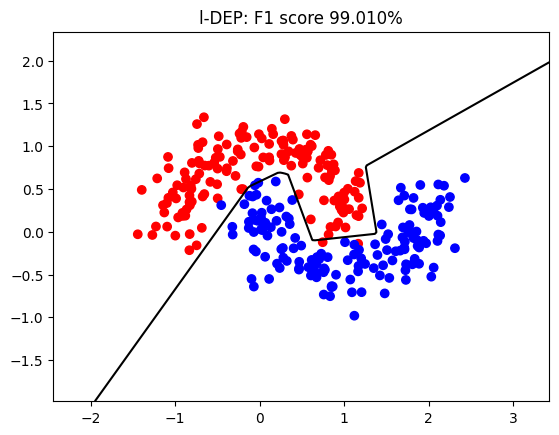

In [6]:
# draw the decision boundary
disp = DecisionBoundaryDisplay.from_estimator(
    ldep, X_test, response_method='decision_function',
    grid_resolution=200,
    plot_method='contour',
    levels=[0],
    colors='black'
)

# add the points
ax = disp.ax_
ax.scatter(*X_test.T, color=y_test)
ax.title.set_text(f'l-DEP: F1 score {score_test * 100:.3f}%')
plt.show()

For good measure, it is also possible to display the results on the training set, which often results in a higher score since the model was trained on it.

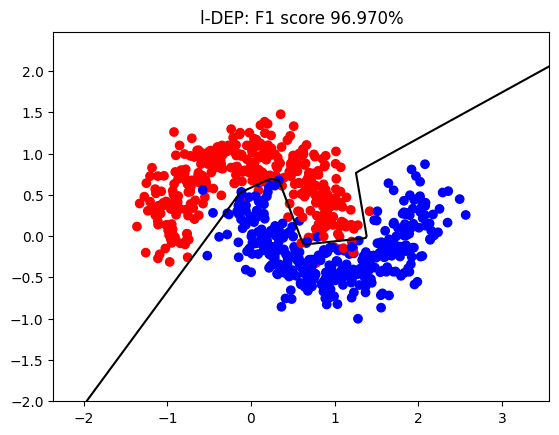

In [7]:
# calculate the F1 score for the training set
score_train = f1_score(y_train, ldep.predict(X_train), pos_label=np.unique(y)[1])

# draw the decision boundary
disp = DecisionBoundaryDisplay.from_estimator(
    ldep, X_train, response_method='decision_function',
    grid_resolution=200,
    plot_method='contour',
    levels=[0],
    colors='black'
)

# add the points
ax = disp.ax_
ax.scatter(*X_train.T, color=y_train)
ax.title.set_text(f'l-DEP: F1 score {score_train * 100:.3f}%')
plt.show()